Partie 1: Exploitation

Étape 1 — Charger les datasets

In [1]:
import pandas as pd

users = pd.read_csv("dataverse_files/users_fr.csv")
items = pd.read_csv("dataverse_files/items_fr.csv")
interactions = pd.read_csv("dataverse_files/explicit_ratings_fr.csv")

Étape 2 — Leurs dimensions

In [6]:
print(users.shape)
print(items.shape)
print(interactions.shape)

(121345, 2)
(1451, 12)
(85339, 5)
Nombre utilisateurs : 121345
Nombre cours : 1451
Nombre interactions : 85339


VALIDATION STRUCTURE & TYPES:

In [3]:
print(" DATA Types: ")
print(items.dtypes)
print(interactions.dtypes)

# Conversion date
interactions["created_at"] = pd.to_datetime(interactions["created_at"], errors="coerce")

print("\n Après DATE Conversation:")
print(interactions.dtypes)

 DATA Types: 
item_id          int64
language        object
name            object
nb_views       float64
description     object
created_at       int64
Difficulty      object
Job             object
Software        object
Theme           object
duration       float64
type            object
dtype: object
user_id              int64
item_id              int64
watch_percentage     int64
created_at          object
rating               int64
dtype: object

 Après DATE Conversation:
user_id                      int64
item_id                      int64
watch_percentage             int64
created_at          datetime64[ns]
rating                       int64
dtype: object


Étape 3 — Vérification des valeurs manquantes

In [14]:
print(interactions.isnull().sum())
print(items.isnull().sum())
print(users.isnull().sum())

user_id             0
item_id             0
watch_percentage    0
created_at          0
rating              0
dtype: int64
item_id           0
language          0
name              0
nb_views         59
description     230
created_at        0
Difficulty     1102
Job               0
Software          0
Theme             0
duration          0
type              0
dtype: int64
user_id         0
job        112288
dtype: int64


Étape 4 — Analyse des contenus

In [5]:
items["Difficulty"].value_counts()

Difficulty
Intermediate    154
Beginner        115
Advanced         80
Name: count, dtype: int64

Étape 5 — Activité utilisateurs

Nombre d’interactions par utilisateur :





In [6]:
interactions.groupby("user_id").size().describe()

count    9789.000000
mean        8.717847
std        28.754770
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max       880.000000
dtype: float64

Étape 6 — Popularité des contenus

In [7]:
interactions.groupby("item_id").size().sort_values(ascending=False).head(10)

item_id
96        1484
97         945
59202      855
324389     624
480        587
21343      568
98         551
102274     531
83         525
21344      507
dtype: int64

Étape 7 — Distribution des notes

les utilisateurs donnent-ils surtout 10 ?

dataset biaisé ?

<Axes: >

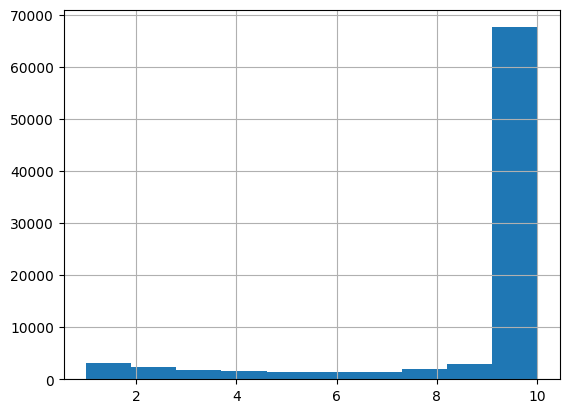

In [8]:
interactions["rating"].hist()

2 Histogramme du nombre d'interactions par utilisateur:

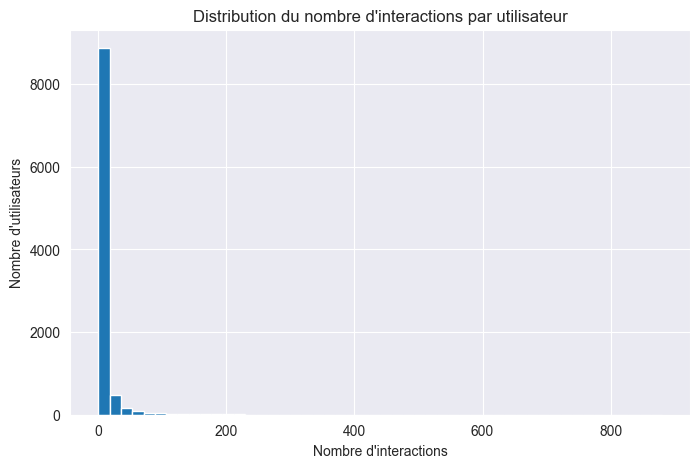

In [7]:
import matplotlib.pyplot as plt

user_interactions = interactions.groupby("user_id").size()

plt.figure(figsize=(8,5))
plt.hist(user_interactions, bins=50)

plt.title("Distribution du nombre d'interactions par utilisateur")
plt.xlabel("Nombre d'interactions")
plt.ylabel("Nombre d'utilisateurs")

plt.show()

3 Distribution des interactions par cours

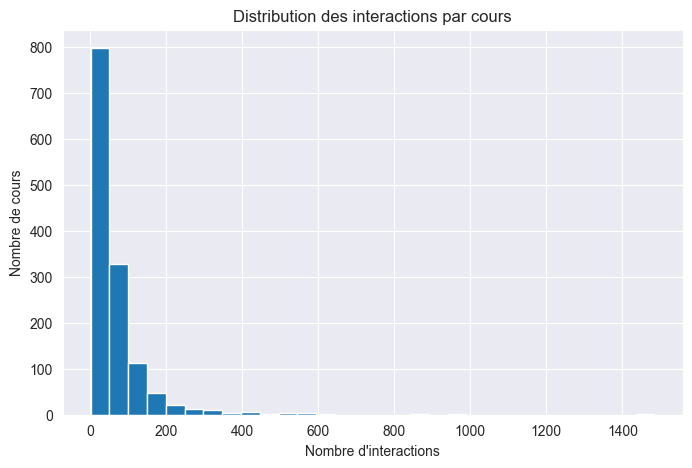

count    1350.000000
mean       63.214074
std        89.742458
min         1.000000
25%        16.000000
50%        39.500000
75%        77.000000
max      1484.000000
dtype: float64


In [8]:
item_interactions = interactions.groupby("item_id").size()

plt.figure(figsize=(8,5))
plt.hist(item_interactions, bins=30)

plt.title("Distribution des interactions par cours")
plt.xlabel("Nombre d'interactions")
plt.ylabel("Nombre de cours")
plt.show()

print(item_interactions.describe())

Étape 8 — Création matrice User–Item



In [9]:
matrix = interactions.pivot_table(
    index="user_id",
    columns="item_id",
    values="rating"
)

Étape 9 — Sparsity :

Un système de recommandation dépend du taux de remplissage.

In [13]:
n_users = interactions["user_id"].nunique()
n_items = interactions["item_id"].nunique()
n_interactions = len(interactions)

sparsity = 1 - (n_interactions / (n_users * n_items))

print("Nombre utilisateurs :", n_users)
print("Nombre cours :", n_items)
print("Nombre interactions :", n_interactions)
print("Sparsité :", round(sparsity * 100, 2), "%")



Nombre utilisateurs : 9789
Nombre cours : 1350
Nombre interactions : 85339
Sparsité : 99.35 %


Étape 10 — Activité utilisateurs

Objectif :

détecter utilisateurs passifs

cold-start users

qui est Important pour le choix d’algorithme.

<Axes: >

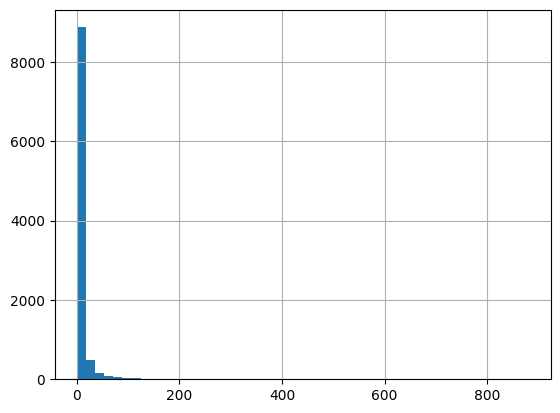

In [11]:
user_activity = interactions.groupby("user_id").size()

user_activity.describe()
user_activity.hist(bins=50)

Étape 11 —Long tail analysis

Montre que peu d’items dominent :

<Axes: xlabel='item_id'>

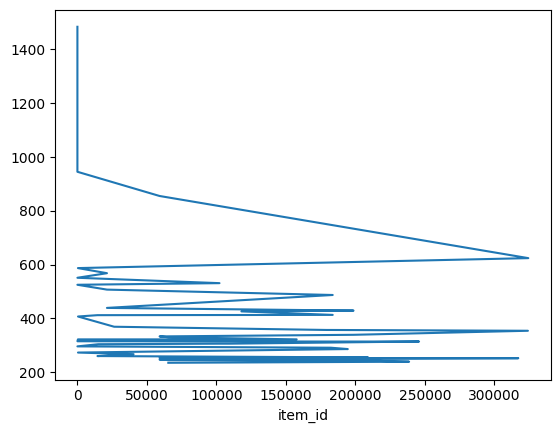

In [12]:
item_popularity = interactions.groupby("item_id").size()
item_popularity.sort_values(ascending=False).head(50).plot()

Étape 12 — Corrélation comportementale

Analyse relation: regarder longtemps ⇒ meilleure note ?

watch_percentage

rating (notation)


<Axes: xlabel='watch_percentage', ylabel='rating'>

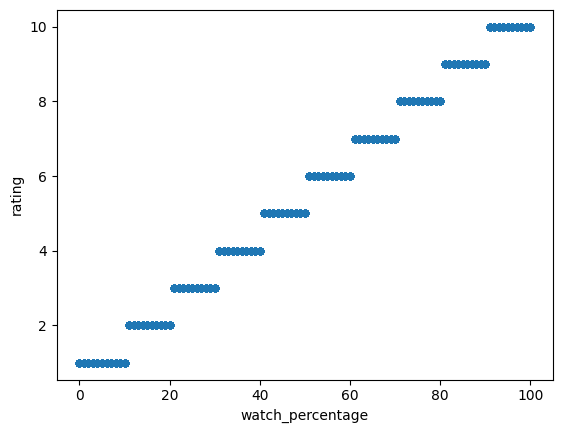

In [13]:
interactions.plot.scatter(
    x="watch_percentage",
    y="rating",
    alpha=0.2
)

Étape 13 — Cold Start Simulation

 utilisateurs avec peu d’interactions --> nécessité hybrid recommender.

In [14]:
(interactions.groupby("user_id").size() < 5).mean()

0.6949637348043722

Partie 2: Nettoyage

Étape 1 — Supprimer bruit utilisateurs

Pour : réduit cold start artificiel et pour éviter faux signaux IA.



In [15]:
# garder utilisateurs actifs
user_counts = interactions.groupby("user_id").size()
active_users = user_counts[user_counts >= 3].index

interactions = interactions[
    interactions["user_id"].isin(active_users)
]

Étape 2 — Supprimer items morts

Pour : Eviter une recommandations instables.

In [16]:
#Supprimer items trop rares
item_counts = interactions.groupby("item_id").size()
popular_items = item_counts[item_counts >= 5].index

interactions = interactions[
    interactions["item_id"].isin(popular_items)
]


Étape 3 — Normaliser ratings

Pour : Améliore collaborative filtering.

In [17]:
interactions["rating_norm"] = (
    interactions["rating"] - interactions["rating"].mean()
)

Étape 4 — Nettoyage texte (pour futur IA)

Nettoyage des colonnes texte


In [18]:
# Nettoyage du nom du cours
items["name"] = items["name"].str.lower().str.strip()

# Nettoyage description
items["description"] = items["description"].fillna("").str.lower().str.strip()

# Nettoyage des colonnes catégorielles
items["language"] = items["language"].str.lower().str.strip()
items["Difficulty"] = items["Difficulty"].str.lower().str.strip()
items["Job"] = items["Job"].fillna("").str.lower().str.strip()
items["Software"] = items["Software"].fillna("").str.lower().str.strip()
items["Theme"] = items["Theme"].fillna("").str.lower().str.strip()
items["type"] = items["type"].str.lower().str.strip()

#Nettoyage Users
users = users.drop_duplicates(subset="user_id")
users["job"] = users["job"].fillna("").str.lower().str.strip()

Étape 5 — Conversion des types et Nettoyage de dates

In [19]:
# nb_views doit être entier
items["nb_views"] = items["nb_views"].fillna(0).astype(int)

# duration doit être numérique
items["duration"] = pd.to_numeric(items["duration"], errors="coerce")
items["duration"] = items["duration"].fillna(items["duration"].median())

#Nettoyage dates
items["created_at"] = pd.to_datetime(items["created_at"], errors="coerce")

interactions["created_at"] = pd.to_datetime(
    interactions["created_at"], errors="coerce"
)

Étape 6 — Supprimer doublons

In [20]:
items = items.drop_duplicates(subset="item_id")

interactions = interactions.drop_duplicates(
    subset=["user_id", "item_id"]
)


print("Duplicat interactions:", interactions.duplicated().sum())
print("Duplicat items:", items.duplicated().sum())

interactions = interactions.drop_duplicates()
items = items.drop_duplicates()

Duplicat interactions: 0
Duplicat items: 0


supprimer les doublons (user_id, item_id) est fondamental, sinon le modèle croit qu’un utilisateur a interagi plusieurs fois avec le même item.

Étape 7 — Vérification cohérence FK

In [21]:
interactions = interactions[
    interactions["item_id"].isin(items["item_id"])
]

Étape 8 — Vérification finale cohérence

In [22]:
print("Users:", interactions["user_id"].nunique())
print("Items:", interactions["item_id"].nunique())
print("Interactions:", len(interactions))

Users: 4468
Items: 1223
Interactions: 78101


 Partie 3: Analyse

Étape 1 — Analyse de la matrice User–Item

0.014292788694164591

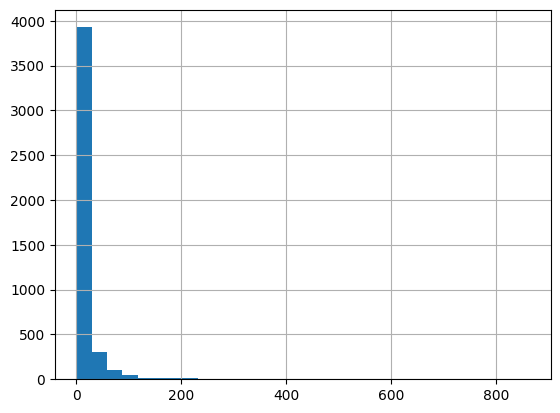

In [23]:
#Nombre d’interactions par utilisateur
interactions.groupby("user_id").size().describe()
#histogramme
interactions.groupby("user_id").size().hist(bins=30)

#Nombre d’interactions par item
interactions.groupby("item_id").size().describe()

#Densité de la matrice
#Si densité < 1%, dataset très sparse → impact modèle.

n_users = interactions["user_id"].nunique()
n_items = interactions["item_id"].nunique()
n_interactions = len(interactions)

density = n_interactions / (n_users * n_items)
density



In [24]:
#Analyse temporelle
#Courbe d’évolution des interactions -→ Voir s’il y a dérive temporelle

interactions["created_at"].dt.year.value_counts().sort_index()

# Analyse croisée:
# Ça montre : biais structurel et la dominance d’une catégorie
items.groupby("Difficulty")["nb_views"].mean()

#Vérification qualité données

items["nb_views"].describe()


count    1451.000000
mean      296.228808
std       442.954943
min         0.000000
25%        82.000000
50%       177.000000
75%       335.000000
max      7287.000000
Name: nb_views, dtype: float64

Étape 2 — Analyse de sparsité visuelle:

Pour montre graphiquement le problème fondamental du collaborative filtering.

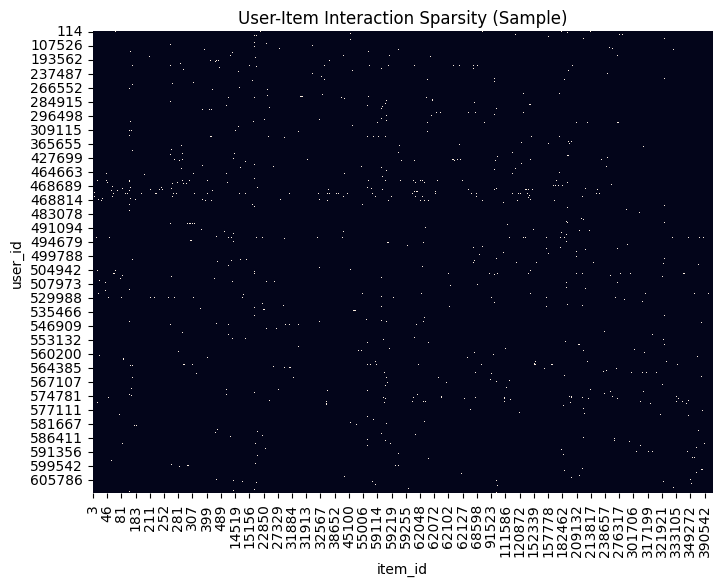

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sample = interactions.sample(5000)

pivot = sample.pivot_table(index="user_id", columns="item_id", aggfunc="size", fill_value=0)

plt.figure(figsize=(8,6))
sns.heatmap(pivot != 0, cbar=False)
plt.title("User-Item Interaction Sparsity (Sample)")
plt.show()

La matrice d'interaction utilisateur-article est très clairsemée. La plupart des utilisateurs n'interagissent qu'avec une petite fraction des articles disponibles. Cette rareté est typique des systèmes de recommandation réels et justifie le recours au filtrage collaboratif ou à des approches de recommandation hybrides.

In [26]:
n_users = interactions["user_id"].nunique()
n_items = interactions["item_id"].nunique()
n_interactions = len(interactions)

sparsity = 1 - (n_interactions / (n_users * n_items))

print("Users:", n_users)
print("Items:", n_items)
print("Interactions:", n_interactions)
print("Sparsity:", round(sparsity, 4))

Users: 4468
Items: 1223
Interactions: 78101
Sparsity: 0.9857


L'ensemble de données est très clairsemé (clairsemence > 0,98), ce qui est typique des systèmes de recommandation.


Étape 3 — Analyse Cold Start:

Qui explique :

combien d’utilisateurs n’ont qu’une seule interaction

impact sur modèle CF

In [27]:
(interactions.groupby("user_id").size() == 1).sum()

0

In [28]:
#Combien d’items ont ≤ 2 interactions:
user_counts = interactions["user_id"].value_counts()
cold_users = (user_counts <= 2).sum()
print("Number of cold users (≤ 2 interactions):", cold_users)

#Combien d’items ont > 2 interactions:
user_counts = interactions["user_id"].value_counts()
cold_users = (user_counts > 2).sum()
print("Number of cold users (> 2 interactions):", cold_users)


# Users
user_counts = interactions["user_id"].value_counts()
cold_users = (user_counts <= 2).sum()
cold_users_pct = cold_users / len(user_counts) * 100

Number of cold users (≤ 2 interactions): 8
Number of cold users (> 2 interactions): 4460


Étape 4 — Analyse déséquilibre catégories:

Si une catégorie domine à 80%, ton modèle sera biaisé.

In [29]:
items["Difficulty"].value_counts(normalize=True)
items["Theme"].value_counts(normalize=True)

Theme
['produire']                                                0.209511
[]                                                          0.125431
['découvrir']                                               0.068229
["s'organiser"]                                             0.062715
['mobilité']                                                0.062026
                                                              ...   
['collaborer', 'produire', 'partager', "s'organiser"]       0.000689
['nouveauté', 'accessibilité']                              0.000689
['mobilité', 'personnaliser']                               0.000689
['collaborer', 'communiquer', 'partager', "s'organiser"]    0.000689
['collaborer', 'communiquer', 'rechercher', 'partager']     0.000689
Name: proportion, Length: 77, dtype: float64

Étape 5 — LONG-TAIL DISTRIBUTION

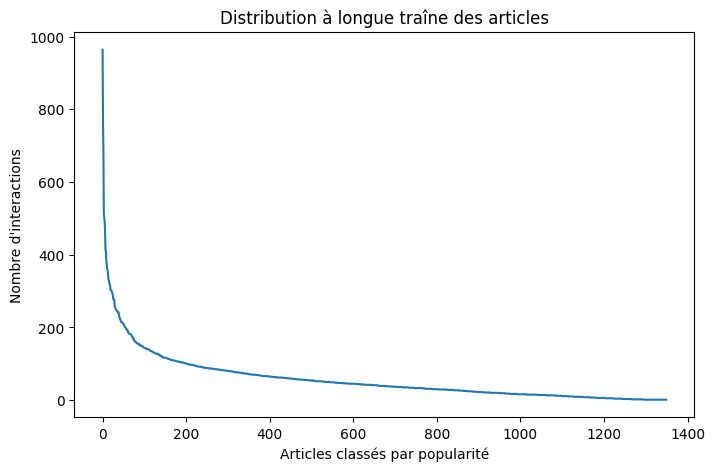

In [30]:
import matplotlib.pyplot as plt

item_counts_sorted = item_counts.sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.plot(item_counts_sorted.values)
plt.title("Distribution à longue traîne des articles")
plt.xlabel("Articles classés par popularité")
plt.ylabel("Nombre d'interactions")
plt.show()

La courbe chute rapidement → vraie long tail.


Étape 6 — ANALYSE DE CONTENU

In [31]:
print("Difficulty distribution:")
print(items["Difficulty"].value_counts())

print("\nType distribution:")
print(items["type"].value_counts())

print("\nTheme distribution:")
print(items["Theme"].value_counts())

Difficulty distribution:
Difficulty
intermediate    154
beginner        115
advanced         80
Name: count, dtype: int64

Type distribution:
type
tutorial    1260
use_case     111
webcast       80
Name: count, dtype: int64

Theme distribution:
Theme
['produire']                                                304
[]                                                          182
['découvrir']                                                99
["s'organiser"]                                              91
['mobilité']                                                 90
                                                           ... 
['collaborer', 'produire', 'partager', "s'organiser"]         1
['nouveauté', 'accessibilité']                                1
['mobilité', 'personnaliser']                                 1
['collaborer', 'communiquer', 'partager', "s'organiser"]      1
['collaborer', 'communiquer', 'rechercher', 'partager']       1
Name: count, Length: 77, dtype: int64


Le dataset présente une forte sparsité, ce qui rend les méthodes de Collaborative Filtering particulièrement adaptées pour exploiter les interactions utilisateur-cours. La présence de métadonnées riches sur les cours (catégories, tags, description) permet également d’envisager un modèle hybride combinant filtrage collaboratif et filtrage basé sur le contenu. Le problème du cold start pour les nouveaux utilisateurs peut être atténué par un modèle basé sur la popularité des cours. Enfin, le déséquilibre entre catégories de cours suggère la nécessité d’appliquer des techniques de régularisation ou de pondération afin d’éviter un biais dans les recommandations.


In [32]:
# corriger job
users["job"] = users["job"].fillna("unknown")

# supprimer mauvaise normalisation
interactions = interactions.drop(columns=["rating_norm"], errors="ignore")
# normalisation correcte
interactions["rating_norm"] = interactions["rating"] / 10

Partie 4 : Exporter version propre

In [33]:
items.to_csv("final_items.csv", index=False)
users.to_csv("final_users.csv", index=False)
interactions.to_csv("final_interactions.csv", index=False)

calculer la Sparsity du dataset

In [34]:
import pandas as pd

items = pd.read_csv("final_items.csv")
interactions = pd.read_csv("final_interactions.csv")

n_users = interactions["user_id"].nunique()
n_items = items["item_id"].nunique()
n_interactions = len(interactions)

sparsity = 1 - (n_interactions / (n_users * n_items))

print("Users:", n_users)
print("Items:", n_items)
print("Interactions:", n_interactions)
print("Sparsity:", round(sparsity, 4))

Users: 4468
Items: 1451
Interactions: 78101
Sparsity: 0.988


La matrice utilisateur-cours est très clairsemée (98,80 %), ce qui est typique des systèmes de recommandation réels. Cette faible densité justifie le recours au filtrage collaboratif et aux approches de recommandation hybrides.

Cold-Start Analysis:

In [35]:
user_counts = interactions["user_id"].value_counts()
item_counts = interactions["item_id"].value_counts()

cold_users = (user_counts <= 2).sum()
cold_items = (item_counts <= 2).sum()

print("Cold users:", cold_users)
print("Cold items:", cold_items)

Cold users: 8
Cold items: 0


Un nombre important d'utilisateurs ont très peu d'interactions, ce qui crée un problème de démarrage à froid et justifie l'utilisation de méthodes de recommandation hybrides.